In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# 1. Read CSV File

In [2]:
df = pd.read_csv("df_final_60min.csv", delimiter=",")

In [3]:
df

,utc_timestamp,cet_cest_timestamp,hour,dayofweek,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_wind_capacity,DE_wind_generation_actual,DE_LU_price_day_ahead,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,price_lag_1h,price_lag_24h,price_lag_168h,price_rolling_mean_24h,price_rolling_std_24h
0,2018-10-07 23:00:00+00:00,2018-10-08 01:00:00+02:00,1,0,42250.0,40888.0,46123.0,0.0,47895.0,7559.0,50.30,0.258819,0.965926,0.000000,1.000000,55.59,47.11,56.10,55.130833,10.897051
1,2018-10-08 00:00:00+00:00,2018-10-08 02:00:00+02:00,2,0,41840.0,40302.0,46123.0,0.0,47895.0,7964.0,50.16,0.500000,0.866025,0.000000,1.000000,50.30,45.75,51.41,55.263750,10.814103
2,2018-10-08 01:00:00+00:00,2018-10-08 03:00:00+02:00,3,0,42316.0,40780.0,46123.0,0.0,47895.0,8260.0,47.32,0.707107,0.707107,0.000000,1.000000,50.16,43.02,47.38,55.447500,10.682080
3,2018-10-08 02:00:00+00:00,2018-10-08 04:00:00+02:00,4,0,44578.0,42508.0,46123.0,0.0,47895.0,8793.0,47.94,0.866025,0.500000,0.000000,1.000000,47.32,42.50,47.59,55.626667,10.499069
4,2018-10-08 03:00:00+00:00,2018-10-08 05:00:00+02:00,5,0,48840.0,46653.0,46123.0,0.0,47895.0,9347.0,51.14,0.965926,0.258819,0.000000,1.000000,47.94,43.80,51.61,55.853333,10.259339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17371,2020-09-30 18:00:00+00:00,2020-09-30 20:00:00+02:00,20,2,61177.0,60443.0,50508.0,0.0,50452.0,8526.0,55.34,-0.866025,0.500000,0.974928,-0.222521,72.43,73.14,53.01,52.107083,10.915879
17372,2020-09-30 19:00:00+00:00,2020-09-30 21:00:00+02:00,21,2,57559.0,56708.0,50508.0,0.0,50452.0,10654.0,49.92,-0.707107,0.707107,0.974928,-0.222521,55.34,57.50,49.89,51.365417,9.990135
17373,2020-09-30 20:00:00+00:00,2020-09-30 22:00:00+02:00,22,2,54108.0,53270.0,50508.0,0.0,50452.0,11836.0,42.79,-0.500000,0.866025,0.974928,-0.222521,49.92,51.57,39.02,51.049583,9.907236
17374,2020-09-30 21:00:00+00:00,2020-09-30 23:00:00+02:00,23,2,49845.0,49239.0,50508.0,0.0,50452.0,12168.0,35.02,-0.258819,0.965926,0.974928,-0.222521,42.79,45.36,32.45,50.683750,10.048284


In [4]:
print("Dataset shape:", df.shape)
print("First timestamp:", df["utc_timestamp"].iloc[0])
print("Last timestamp:", df["utc_timestamp"].iloc[-1])

Dataset shape: (17376, 20)
First timestamp: 2018-10-07 23:00:00+00:00
Last timestamp: 2020-09-30 22:00:00+00:00


# 2. XGBoost Price Prediction

The first part trains a standard XGBoost regression model to predict the
German-Luxembourg day-ahead electricity price.

## 2.1 Define the XGBoost features and target

For the predictive XGBoost model:

- `X` contains the explanatory variables.
- `y` contains the day-ahead electricity price.


In [5]:
features = [
    "hour",
    "dayofweek",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "DE_load_actual_entsoe_transparency",
    "DE_load_forecast_entsoe_transparency",
    "DE_solar_capacity",
    "DE_solar_generation_actual",
    "DE_wind_capacity",
    "DE_wind_generation_actual",
    "price_lag_1h",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_mean_24h",
    "price_rolling_std_24h",
]

xgboost_target = "DE_LU_price_day_ahead"

random_seed = 42

X = df[features]
y = df[xgboost_target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17376, 17)
y shape: (17376,)


## 2.2 Split the data into training and test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False,   ## dataset is a time series, `shuffle=False` --> earlier observations are used for training and later observations for testing.
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13900, 17)
X_test shape: (3476, 17)
y_train shape: (13900,)
y_test shape: (3476,)


## 2.3 Define the XGBoost hyperparameters

In [7]:
def create_xgboost_model(random_state=random_seed):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=350,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=random_state,
        n_jobs=-1,
        tree_method="hist",
    )

    return model

## 2.4 Train the XGBoost model

In [8]:
xgboost_model = create_xgboost_model(random_state=random_seed)

xgboost_model.fit(
    X_train,
    y_train,
)

y_pred = xgboost_model.predict(X_test)


## 2.5 Evaluate the XGBoost model

In [9]:
### R² measures the explained variation.
xgboost_r2 = r2_score(
    y_test,
    y_pred,
)


## RMSE which measures the average prediction error in EUR/MWh.
xgboost_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred,
    )
)

print("XGBoost test R2:", xgboost_r2)
print("XGBoost test RMSE:", xgboost_rmse)

XGBoost test R2: 0.9172359326556841
XGBoost test RMSE: 4.7731909718770975


## 2.6 Plot actual and predicted electricity prices


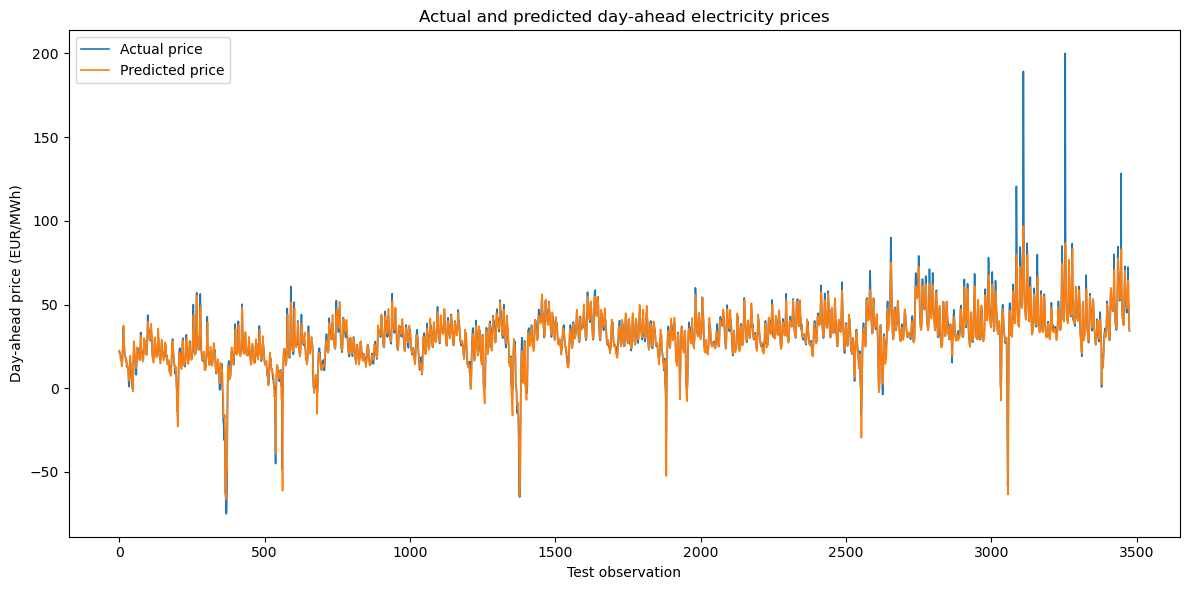

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.to_numpy(),
    label="Actual price",
    linewidth=1.2,
)

plt.plot(
    y_pred,
    label="Predicted price",
    linewidth=1.2,
)

plt.xlabel("Test observation")
plt.ylabel("Day-ahead price (EUR/MWh)")
plt.title("Actual and predicted day-ahead electricity prices")
plt.legend()
plt.tight_layout()


plt.show()

# 3. Explain XGBoost Model with SHAP

In [11]:
shap_explainer = shap.TreeExplainer(xgboost_model)

In [12]:
shap_values = shap_explainer(X_test)

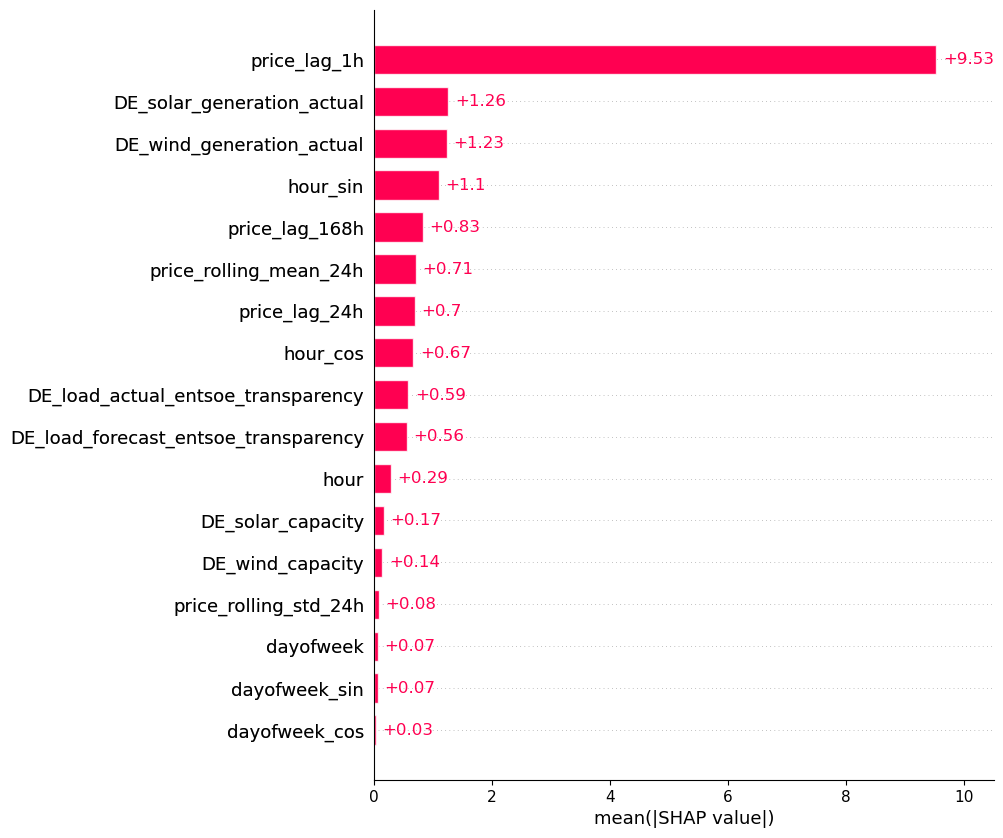

In [13]:
shap.plots.bar(shap_values, max_display=20)

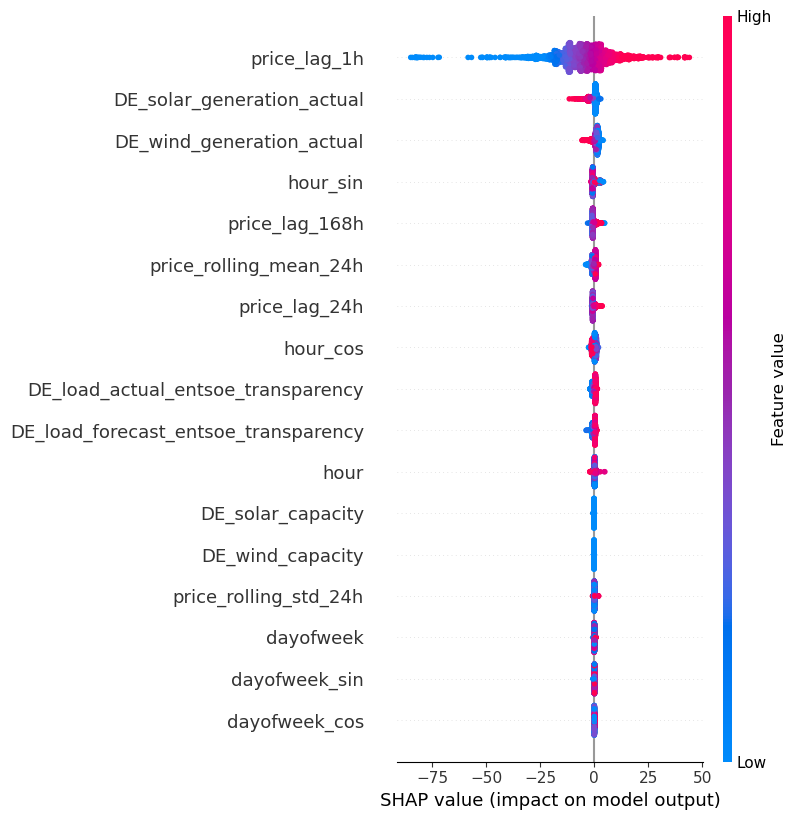

In [14]:
# SHAP summary plot
shap.summary_plot(
    shap_values.values,
    X_test,
    feature_names=X_test.columns,
    max_display=20
)

# 4. NLO Double Machine Learning (Solar treatment)

## 4.1 Define the DML outcome, treatment, and controls 

In [15]:
dml_outcome = "DE_LU_price_day_ahead"
dml_solar_treatment = "DE_solar_generation_actual"

dml_solar_controls = [
    "hour",
    "dayofweek",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "DE_load_actual_entsoe_transparency",
    "DE_load_forecast_entsoe_transparency",
    "DE_solar_capacity",
    "DE_wind_capacity",
    "DE_wind_generation_actual",
    "price_lag_1h",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_mean_24h",
    "price_rolling_std_24h",
]

Y_dml = df[dml_outcome].to_numpy(dtype=float)
D_dml = df[dml_solar_treatment].to_numpy(dtype=float)
X_dml = df[dml_solar_controls].copy()

print("DML outcome:", dml_outcome)
print("DML solar treatment:", dml_solar_treatment)
print("Number of DML controls:", len(dml_solar_controls))

DML outcome: DE_LU_price_day_ahead
DML solar treatment: DE_solar_generation_actual
Number of DML controls: 16


## 4.2 Define the NLO-DML settings

The observations are divided into chronological folds.

For each test fold, the test fold and its neighbouring folds are excluded from
nuisance-model training.

HAC standard errors are used in the final residual regression.

In [16]:
N_FOLDS = 8
N_NEIGHBOURS_LEFT_OUT = 1
HAC_MAXLAGS = 168

## 4.3 Define the complete NLO-DML procedure

The function performs the full procedure:

1. Divide the observations into chronological folds.
2. Exclude the test fold and its neighbouring folds.
3. Estimate \(E[Y|X]\) with XGBoost.
4. Estimate \(E[D|X]\) with XGBoost.
5. Create cross-fitted residuals.
6. Estimate the DML coefficient.
7. Calculate HAC standard errors and confidence intervals.
8. Return the causal results, diagnostics, and residuals.

In [17]:
def run_nlo_dml(X, Y, D,
    n_folds=8,
    neighbours_left_out=1,
    hac_maxlags=168):
    
    all_indices = np.arange(len(Y))

    folds = np.array_split(
        all_indices,
        n_folds,
    )

    y_hat = np.full(
        len(Y),
        np.nan,
    )

    d_hat = np.full(
        len(D),
        np.nan,
    )

    fold_diagnostics = []

    for test_fold_number in range(n_folds):
        first_excluded_fold = max(
            0,
            test_fold_number - neighbours_left_out,
        )

        last_excluded_fold = min(
            n_folds - 1,
            test_fold_number + neighbours_left_out,
        )

        excluded_folds = list(
            range(
                first_excluded_fold,
                last_excluded_fold + 1,
            )
        )

        test_indices = folds[test_fold_number]

        train_parts = []

        for fold_number in range(n_folds):
            if fold_number not in excluded_folds:
                train_parts.append(
                    folds[fold_number]
                )

        if len(train_parts) == 0:
            raise ValueError(
                "No training folds remain. "
                "Increase n_folds or reduce neighbours_left_out."
            )

        train_indices = np.concatenate(
            train_parts
        )

        outcome_model = create_xgboost_model(
            random_state=(
                random_seed
                + test_fold_number
            )
        )

        treatment_model = create_xgboost_model(
            random_state=(
                random_seed
                + 100
                + test_fold_number
            )
        )

        outcome_model.fit(
            X.iloc[train_indices],
            Y[train_indices],
        )

        treatment_model.fit(
            X.iloc[train_indices],
            D[train_indices],
        )

        y_hat[test_indices] = outcome_model.predict(
            X.iloc[test_indices]
        )

        d_hat[test_indices] = treatment_model.predict(
            X.iloc[test_indices]
        )

        fold_diagnostics.append(
            {
                "test_fold": test_fold_number,
                "excluded_folds": str(excluded_folds),
                "train_size": len(train_indices),
                "test_size": len(test_indices),
                "outcome_r2": r2_score(
                    Y[test_indices],
                    y_hat[test_indices],
                ),
                "outcome_rmse": np.sqrt(
                    mean_squared_error(
                        Y[test_indices],
                        y_hat[test_indices],
                    )
                ),
                "treatment_r2": r2_score(
                    D[test_indices],
                    d_hat[test_indices],
                ),
                "treatment_rmse": np.sqrt(
                    mean_squared_error(
                        D[test_indices],
                        d_hat[test_indices],
                    )
                ),
            }
        )

        print(
            f"Finished NLO fold {test_fold_number}"
        )

    if np.isnan(y_hat).any():
        raise ValueError(
            "Some outcome predictions are missing."
        )

    if np.isnan(d_hat).any():
        raise ValueError(
            "Some treatment predictions are missing."
        )

    y_residual = Y - y_hat
    d_residual = D - d_hat

    final_model = sm.OLS(
        y_residual,
        d_residual.reshape(-1, 1),
    )

    final_result = final_model.fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": hac_maxlags,
            "use_correction": True,
        },
    )

    effect_per_mw = float(
        final_result.params[0]
    )

    standard_error_per_mw = float(
        final_result.bse[0]
    )

    confidence_interval = final_result.conf_int(
        alpha=0.05
    )[0]

    dml_results = {
        "effect_per_MW": effect_per_mw,
        "standard_error_per_MW": standard_error_per_mw,
        "p_value": float(
            final_result.pvalues[0]
        ),
        "ci_95_low_per_MW": float(
            confidence_interval[0]
        ),
        "ci_95_high_per_MW": float(
            confidence_interval[1]
        ),
        "effect_per_GW": effect_per_mw * 1000,
        "standard_error_per_GW": (
            standard_error_per_mw * 1000
        ),
        "ci_95_low_per_GW": (
            float(confidence_interval[0]) * 1000
        ),
        "ci_95_high_per_GW": (
            float(confidence_interval[1]) * 1000
        ),
    }

    diagnostics = pd.DataFrame(
        fold_diagnostics
    )

    residuals = pd.DataFrame(
        {
            "outcome_actual": Y,
            "outcome_prediction": y_hat,
            "outcome_residual": y_residual,
            "solar_actual_MW": D,
            "solar_prediction_MW": d_hat,
            "solar_residual_MW": d_residual,
        }
    )

    return dml_results, diagnostics, residuals

## 4.4 Run the NLO-DML estimation

The DML function is now applied to the selected outcome, treatment, and control
variables.

In [18]:
dml_results, dml_diagnostics, dml_residuals = run_nlo_dml(
    X=X_dml,
    Y=Y_dml,
    D=D_dml,
    n_folds=N_FOLDS,
    neighbours_left_out=N_NEIGHBOURS_LEFT_OUT,
    hac_maxlags=HAC_MAXLAGS,
)

Finished NLO fold 0
Finished NLO fold 1
Finished NLO fold 2
Finished NLO fold 3
Finished NLO fold 4
Finished NLO fold 5
Finished NLO fold 6
Finished NLO fold 7


## 4.5 Inspect nuisance-model performance

These diagnostics show how accurately XGBoost predicts:

- the outcome from the controls,
- the treatment from the controls.


In [19]:
print(dml_diagnostics.round(4))

print(
    "Average outcome-model R2:",
    dml_diagnostics["outcome_r2"].mean(),
)

print(
    "Average treatment-model R2:",
    dml_diagnostics["treatment_r2"].mean(),
)

   test_fold excluded_folds  train_size  test_size  outcome_r2  outcome_rmse  \
0          0         [0, 1]       13032       2172      0.8798        6.7928   
1          1      [0, 1, 2]       10860       2172      0.9242        4.8217   
2          2      [1, 2, 3]       10860       2172      0.9049        4.8821   
3          3      [2, 3, 4]       10860       2172      0.9258        3.1999   
4          4      [3, 4, 5]       10860       2172      0.9168        4.1686   
5          5      [4, 5, 6]       10860       2172      0.9342        3.8675   
6          6      [5, 6, 7]       10860       2172      0.8730        5.2347   
7          7         [6, 7]       13032       2172      0.8815        5.5689   

   treatment_r2  treatment_rmse  
0       -1.7070       6228.6802  
1        0.3939       4352.0493  
2        0.3885       7101.1703  
3        0.8718       2874.9064  
4       -2.9980       7132.4679  
5        0.1184       5630.0108  
6        0.2775       8280.7121  
7      

## 4.6 Report the DML causal estimate


In [20]:
print("\nNLO-DML causal estimate")
print("-----------------------")

print(
    "Effect of +1 MW solar generation:",
    f"{dml_results['effect_per_MW']:.6f} EUR/MWh",
)

print(
    "Effect of +1 GW solar generation:",
    f"{dml_results['effect_per_GW']:.4f} EUR/MWh",
)

print(
    "HAC standard error per GW:",
    f"{dml_results['standard_error_per_GW']:.4f}",
)

print(
    "95% confidence interval per GW:",
    f"[{dml_results['ci_95_low_per_GW']:.4f}, "
    f"{dml_results['ci_95_high_per_GW']:.4f}]",
)

print(
    "p-value:",
    f"{dml_results['p_value']:.6g}",
)


NLO-DML causal estimate
-----------------------
Effect of +1 MW solar generation: -0.000235 EUR/MWh
Effect of +1 GW solar generation: -0.2351 EUR/MWh
HAC standard error per GW: 0.0180
95% confidence interval per GW: [-0.2704, -0.1999]
p-value: 4.68551e-39


## 4.7 Plot the residualized DML relationship

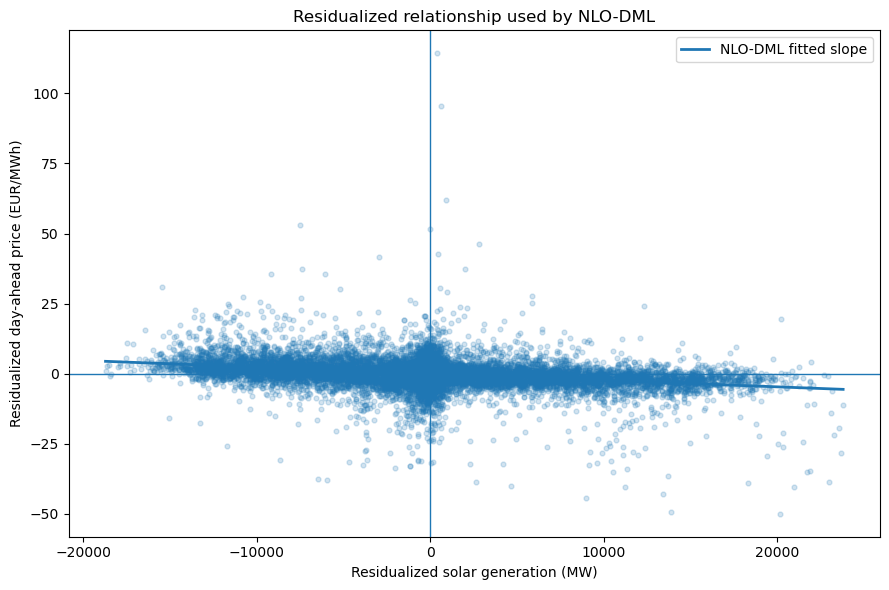

In [21]:
plt.figure(figsize=(9, 6))

plt.scatter(
    dml_residuals["solar_residual_MW"],
    dml_residuals["outcome_residual"],
    alpha=0.20,
    s=12,
)

x_line = np.linspace(
    dml_residuals["solar_residual_MW"].min(),
    dml_residuals["solar_residual_MW"].max(),
    200,
)

y_line = (
    dml_results["effect_per_MW"]
    * x_line
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="NLO-DML fitted slope",
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Residualized solar generation (MW)")

plt.ylabel("Residualized day-ahead price (EUR/MWh)")

plt.title("Residualized relationship used by NLO-DML")

plt.legend()
plt.tight_layout()


plt.show()

# 5. NLO Double Machine Learning (Wind treatment)

## 5.1 Define the DML outcome, treatment, and controls 

In [22]:
dml_outcome = "DE_LU_price_day_ahead"
dml_wind_treatment = "DE_wind_generation_actual"

dml_wind_controls = [
    "hour",
    "dayofweek",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "DE_load_actual_entsoe_transparency",
    "DE_load_forecast_entsoe_transparency",
    "DE_solar_capacity",
    "DE_solar_generation_actual",
    "DE_wind_capacity",
    "price_lag_1h",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_mean_24h",
    "price_rolling_std_24h",
]

Y_dml = df[dml_outcome].to_numpy(dtype=float)
D_dml = df[dml_wind_treatment].to_numpy(dtype=float)
X_dml = df[dml_wind_controls].copy()

print("DML outcome:", dml_outcome)
print("DML wind treatment:", dml_wind_treatment)
print("Number of DML controls:", len(dml_wind_controls))

DML outcome: DE_LU_price_day_ahead
DML wind treatment: DE_wind_generation_actual
Number of DML controls: 16


## 5.2 Define the NLO-DML settings

In [23]:
N_FOLDS = 8
N_NEIGHBOURS_LEFT_OUT = 1
HAC_MAXLAGS = 168

## 5.3 Define the complete NLO-DML procedure


In [24]:
def run_nlo_dml(X, Y, D,
    n_folds=8,
    neighbours_left_out=1,
    hac_maxlags=168):
    
    all_indices = np.arange(len(Y))

    folds = np.array_split(
        all_indices,
        n_folds,
    )

    y_hat = np.full(
        len(Y),
        np.nan,
    )

    d_hat = np.full(
        len(D),
        np.nan,
    )

    fold_diagnostics = []

    for test_fold_number in range(n_folds):
        first_excluded_fold = max(
            0,
            test_fold_number - neighbours_left_out,
        )

        last_excluded_fold = min(
            n_folds - 1,
            test_fold_number + neighbours_left_out,
        )

        excluded_folds = list(
            range(
                first_excluded_fold,
                last_excluded_fold + 1,
            )
        )

        test_indices = folds[test_fold_number]

        train_parts = []

        for fold_number in range(n_folds):
            if fold_number not in excluded_folds:
                train_parts.append(
                    folds[fold_number]
                )

        if len(train_parts) == 0:
            raise ValueError(
                "No training folds remain. "
                "Increase n_folds or reduce neighbours_left_out."
            )

        train_indices = np.concatenate(
            train_parts
        )

        outcome_model = create_xgboost_model(
            random_state=(
                random_seed
                + test_fold_number
            )
        )

        treatment_model = create_xgboost_model(
            random_state=(
                random_seed
                + 100
                + test_fold_number
            )
        )

        outcome_model.fit(
            X.iloc[train_indices],
            Y[train_indices],
        )

        treatment_model.fit(
            X.iloc[train_indices],
            D[train_indices],
        )

        y_hat[test_indices] = outcome_model.predict(
            X.iloc[test_indices]
        )

        d_hat[test_indices] = treatment_model.predict(
            X.iloc[test_indices]
        )

        fold_diagnostics.append(
            {
                "test_fold": test_fold_number,
                "excluded_folds": str(excluded_folds),
                "train_size": len(train_indices),
                "test_size": len(test_indices),
                "outcome_r2": r2_score(
                    Y[test_indices],
                    y_hat[test_indices],
                ),
                "outcome_rmse": np.sqrt(
                    mean_squared_error(
                        Y[test_indices],
                        y_hat[test_indices],
                    )
                ),
                "treatment_r2": r2_score(
                    D[test_indices],
                    d_hat[test_indices],
                ),
                "treatment_rmse": np.sqrt(
                    mean_squared_error(
                        D[test_indices],
                        d_hat[test_indices],
                    )
                ),
            }
        )

        print(
            f"Finished NLO fold {test_fold_number}"
        )

    if np.isnan(y_hat).any():
        raise ValueError(
            "Some outcome predictions are missing."
        )

    if np.isnan(d_hat).any():
        raise ValueError(
            "Some treatment predictions are missing."
        )

    y_residual = Y - y_hat
    d_residual = D - d_hat

    final_model = sm.OLS(
        y_residual,
        d_residual.reshape(-1, 1),
    )

    final_result = final_model.fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": hac_maxlags,
            "use_correction": True,
        },
    )

    effect_per_mw = float(
        final_result.params[0]
    )

    standard_error_per_mw = float(
        final_result.bse[0]
    )

    confidence_interval = final_result.conf_int(
        alpha=0.05
    )[0]

    dml_results = {
        "effect_per_MW": effect_per_mw,
        "standard_error_per_MW": standard_error_per_mw,
        "p_value": float(
            final_result.pvalues[0]
        ),
        "ci_95_low_per_MW": float(
            confidence_interval[0]
        ),
        "ci_95_high_per_MW": float(
            confidence_interval[1]
        ),
        "effect_per_GW": effect_per_mw * 1000,
        "standard_error_per_GW": (
            standard_error_per_mw * 1000
        ),
        "ci_95_low_per_GW": (
            float(confidence_interval[0]) * 1000
        ),
        "ci_95_high_per_GW": (
            float(confidence_interval[1]) * 1000
        ),
    }

    diagnostics = pd.DataFrame(
        fold_diagnostics
    )

    residuals = pd.DataFrame(
        {
            "outcome_actual": Y,
            "outcome_prediction": y_hat,
            "outcome_residual": y_residual,
            "wind_actual_MW": D,
            "wind_prediction_MW": d_hat,
            "wind_residual_MW": d_residual,
        }
    )

    return dml_results, diagnostics, residuals

## 5.4 Run the NLO-DML estimation

In [25]:
dml_results, dml_diagnostics, dml_residuals = run_nlo_dml(
    X=X_dml,
    Y=Y_dml,
    D=D_dml,
    n_folds=N_FOLDS,
    neighbours_left_out=N_NEIGHBOURS_LEFT_OUT,
    hac_maxlags=HAC_MAXLAGS,
)

Finished NLO fold 0
Finished NLO fold 1
Finished NLO fold 2
Finished NLO fold 3
Finished NLO fold 4
Finished NLO fold 5
Finished NLO fold 6
Finished NLO fold 7


## 5.5 Inspect nuisance-model performance

In [26]:
print(dml_diagnostics.round(4))

print(
    "Average outcome-model R2:",
    dml_diagnostics["outcome_r2"].mean(),
)

print(
    "Average treatment-model R2:",
    dml_diagnostics["treatment_r2"].mean(),
)

   test_fold excluded_folds  train_size  test_size  outcome_r2  outcome_rmse  \
0          0         [0, 1]       13032       2172      0.8779        6.8465   
1          1      [0, 1, 2]       10860       2172      0.9230        4.8615   
2          2      [1, 2, 3]       10860       2172      0.9269        4.2799   
3          3      [2, 3, 4]       10860       2172      0.9246        3.2247   
4          4      [3, 4, 5]       10860       2172      0.9219        4.0380   
5          5      [4, 5, 6]       10860       2172      0.9356        3.8262   
6          6      [5, 6, 7]       10860       2172      0.8928        4.8097   
7          7         [6, 7]       13032       2172      0.8832        5.5294   

   treatment_r2  treatment_rmse  
0        0.3950       7692.2115  
1        0.6061       7635.3777  
2       -0.3453       7082.4852  
3        0.5521       4703.8704  
4        0.3270       8219.3202  
5        0.5431       7770.7499  
6       -3.1917      14625.3751  
7      

## 5.6 Report the DML causal estimate

In [27]:
print("\nNLO-DML causal estimate")
print("-----------------------")

print(
    "Effect of +1 MW wind generation:",
    f"{dml_results['effect_per_MW']:.6f} EUR/MWh",
)

print(
    "Effect of +1 GW wind generation:",
    f"{dml_results['effect_per_GW']:.4f} EUR/MWh",
)

print(
    "HAC standard error per GW:",
    f"{dml_results['standard_error_per_GW']:.4f}",
)

print(
    "95% confidence interval per GW:",
    f"[{dml_results['ci_95_low_per_GW']:.4f}, "
    f"{dml_results['ci_95_high_per_GW']:.4f}]",
)

print(
    "p-value:",
    f"{dml_results['p_value']:.6g}",
)


NLO-DML causal estimate
-----------------------
Effect of +1 MW wind generation: -0.000102 EUR/MWh
Effect of +1 GW wind generation: -0.1022 EUR/MWh
HAC standard error per GW: 0.0098
95% confidence interval per GW: [-0.1215, -0.0830]
p-value: 2.45844e-25


## 5.7 Plot the residualized DML relationship

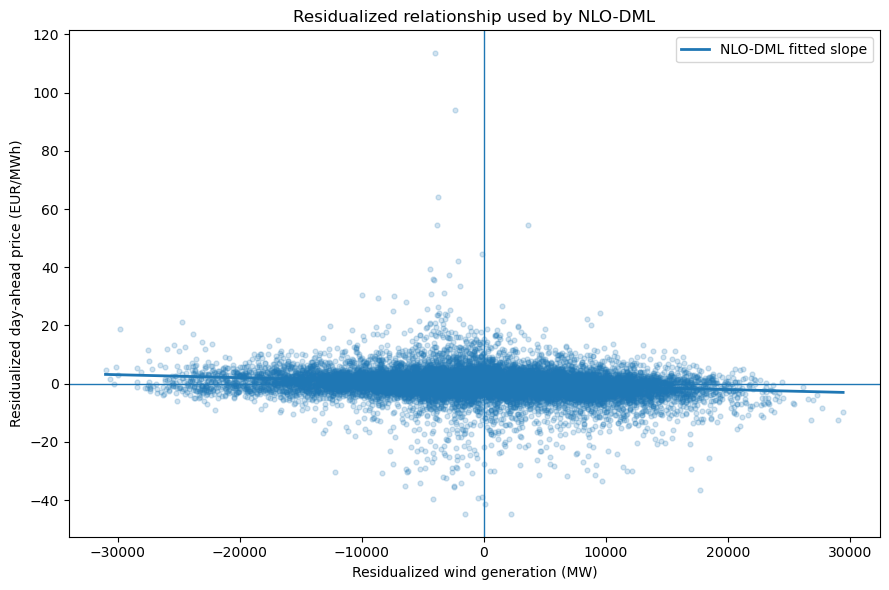

In [28]:
plt.figure(figsize=(9, 6))

plt.scatter(
    dml_residuals["wind_residual_MW"],
    dml_residuals["outcome_residual"],
    alpha=0.20,
    s=12,
)

x_line = np.linspace(
    dml_residuals["wind_residual_MW"].min(),
    dml_residuals["wind_residual_MW"].max(),
    200,
)

y_line = (
    dml_results["effect_per_MW"]
    * x_line
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="NLO-DML fitted slope",
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Residualized wind generation (MW)")

plt.ylabel("Residualized day-ahead price (EUR/MWh)")

plt.title("Residualized relationship used by NLO-DML")

plt.legend()
plt.tight_layout()


plt.show()